# Mini Proyecto Deep Learning - Start-Up basada en IA (FantasIA)
#### Máster Universitario en Ciencia de Datos - Universitat de València

### Adrián Carrasco Alcalá y Clara Montalvá Barcenilla


## Descripción

La idea de la Start-Up es la creación de una aplicación infantil de dibujo y generación de cuentos.

El usuario dibuja su edad y un animal en pantallas interactivas. Se genera la primera parte de un cuento infantil que tiene al animal como protagonista, teniendo en cuenta sus características en el dibujo y utilizando un vocabulario adaptado a la edad del lector. Se acompaña a la historia con la voz de un narrador y una ilustración de la misma.

La primera parte del cuento acaba con la aparición de un segundo animal misterioso, y una pregunta al lector sobre cuál es este nuevo personaje. El usuario dibuja este segundo protagonista en una nueva pantalla interactiva y se genera la segunda y parte final del cuento, con su narrador e ilustración correspondiente.

## Metodología

#### <u>Inputs proporcionados por el usuario</u>
- Dibujo con la edad del niño
- Dibujo del primer animal
- Dibujo del segundo animal

#### <u>Modelos</u>
- Red Neuronal Convolucional (CNN) entrenada con el conjunto MNIST: Identifica la edad dibujada.
- Qwen3-VL: Detecta el animal a partir del dibujo o garabato y genera una pequeña descripción del mismo.
- API Gemini: Genera las partes de la historia a partir de los animales y su descripción. Plantea una pregunta al final de la primera parte y presenta una moraleja al final de la segunda.
- Edge TTS: Genera la voz del narrador que lee la historia.
- Nano Banana 2: Crea las ilustraciones a partir de cada una de las partes de la historia.

#### <u>Outputs</u>
- Texto con la historia completa divida en partes, con la pregunta al final de la primera parte y la moraleja al final de la segunda.
- Audio con la voz del narrador contando la historia.
- Imágenes con las ilustraciones a partir del cuento.

### Diagrama con modelos de IA

<img src="Diagrama_Proyecto_DL_Implementado.jpg" width="1000" height="400">


## Aplicación de los modelos

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import tkinter as tk
from PIL import Image, ImageDraw
from skimage.transform import resize
import matplotlib.pyplot as plt
import asyncio
import os
from rich.console import Console
from rich.panel import Panel
from IPython.display import Image, display

# modulos propios
from modulos.aplicacion_dibujo import AplicacionDibujo
from modulos.edad import deteccion_edad
from modulos import descripcion_dibujo
from google import genai
from modulos.narrador import crear_audiolibro, reproducir_audio

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

c:\Users\sPoKet20\anaconda3\envs\Clase1_25_26\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sPoKet20\.cache\huggingface\hub\models--stabilityai--stable-diffusion-xl-base-1.0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

AssertionError: Torch not compiled with CUDA enabled

### Red Neuronal Convolucional (CNN) para la detección de la edad

Utilizamos una red neuronal entrenada con el conjunto de datos MNIST que sea capaz de identificar el número dibujado por el niño o el padre.

En primer lugar, abrimos la ventana de dibujo que pregunta por la edad.

In [3]:
root = tk.Tk()  # Creamos una ventana básica en blanco
app = AplicacionDibujo(root)

# Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
root.mainloop()

if app.imagen_resultado is not None:
    print("La imagen ha sido guardada.")
    img = app.imagen_resultado
else:
    print("La ventana se cerró sin guardar la imagen.")

La imagen ha sido guardada.


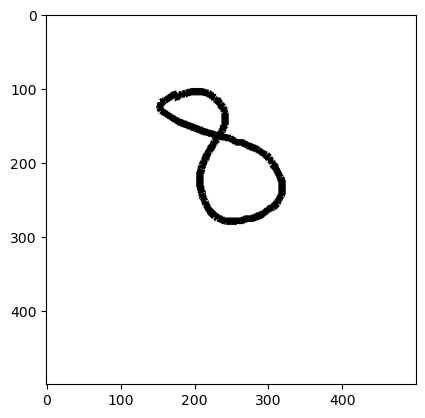

In [ ]:
plt.imshow(img)

Cargamos el modelo y lo aplicamos

In [ ]:
modelo_edad = tf.keras.models.load_model('modelos/CNN_edad.keras')

edad = deteccion_edad(img, modelo_edad)

print("La edad del niño es:", edad)

La edad del niño es: 8


### Modelo Qwen3-VL para identificación y descripción del dibujo del animal

De nuevo abrimos la ventana de dibujo, esta vez preguntando por el animal.

In [6]:
root = tk.Tk()  # Creamos una ventana básica en blanco
app = AplicacionDibujo(root, modo_edad=False)

# Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
root.mainloop()

if app.imagen_resultado is not None:
    print("La imagen ha sido guardada.")
    img_animal = app.imagen_resultado
else:
    print("La ventana se cerró sin guardar la imagen.")

La imagen ha sido guardada.


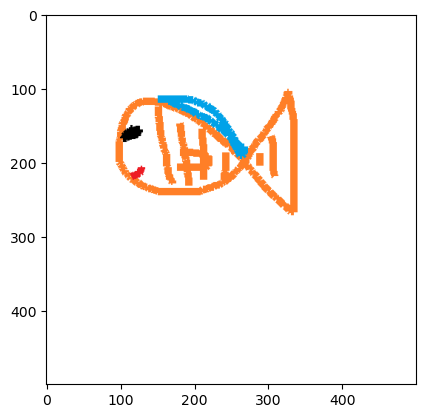

In [31]:
plt.imshow(img_animal)

Aplicamos el modelo Qwen3-VL, con un prompt muy específico (ver `descripcion_dibujo`) para obtener siempre el mismo formato en la salida.

In [ ]:
desc = descripcion_dibujo.descripcion(img_animal)

desc = desc[0].split("assistant")[1].strip()
desc_sep = desc.strip().split('\n')
animal = desc_sep[0].replace("Animal: ", "").strip()
descripcion = desc_sep[1].replace("Description: ", "").strip()

In [32]:
print("Animal:", animal)
print("Descripción:", descripcion)

Animal: Fish
Descripción: A cartoon fish with an orange body, a blue stripe across its back, a black eye, and a red mouth. It has a simple, stylized shape with a pointed tail.


### API Gemini para generación de la primera parte de la historia

Nos conectamos a la API de Gemini y generamos la primera parte de la historia.

In [18]:
# Leemos la clave API desde un archivo de texto
with open("clave.txt", "r", encoding="utf-8") as archivo:
    GEMINI_API_KEY = archivo.read()

In [ ]:
cliente = genai.Client(api_key=GEMINI_API_KEY)

modelo = "gemini-3-flash-preview"
prompt = f'''Eres un experto escritor de cuentos infantiles en español. 
Escribe la primera parte de un cuento que tenga a un/una {animal} como protagonista de la historia. El/La {animal} tiene las siguientes características: {descripcion} (no es necesario que la descripción de ellas sea explícita).
La extensión de esta primera parte debe ser estrictamente de 3 párrafos.
La historia tendrá dos partes, por lo que la trama debe evolucionar rápido. Además, el cuento debe estar escrito específicamente para que lo entienda un niño de {edad} años, utilizando un vocabulario apropiado para esa etapa de desarrollo vital.
Debes tener en cuenta que el texto será leído por un narrador en voz alta, y que se generará una dibujo a partir de él, por lo que debe ser descriptivo y con pausas.
Por último, debe introducirse casi al final de esta primera parte de la historia a un segundo animal desconocido, del cual no se dé una descripción muy detallada para permitir que sea elegido libremente por el niño.
Añade un cuarto párrafo adicional que sea estrictamente una pregunta corta para el niño acerca de cuál es este nuevo animal (la pregunta debe estar en el tiempo verbal de la historia).'''

respuesta = cliente.models.generate_content(
    model = modelo, contents = prompt
)

cuento = respuesta.text

Mostramos el cuento por pantalla de una forma algo más elegante que con un simple `print()`.

In [3]:
console = Console()
console.print(Panel(cuento, expand=False), justify="full")

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Había una vez un pececito llamado Rayo que vivía en un arrecife lleno de colores. Su cuerpo era de  un  naranja │
│ brillante, tan intenso que se podía ver desde muy lejos, y llevaba una raya azul sobre su espalda como si fuera │
│ una pequeña medalla de velocidad. Con su ojo negro siempre atento y su boca roja siempre  lista  para  saludar, │
│ Rayo movía su colita puntiaguda para nadar entre las burbujas. Era el pez más rápido  de  su  grupo  y  siempre │
│ soñaba con vivir una gran aventura fuera de su hogar de coral.                                                  │
│                                                                                                                 │
│ Una mañana, Rayo decidió que era el momento de explorar lo que había más allá de la gran roca  gris.  Nadó  con │
│ mucha fuerza, sintiendo cómo el agua fresca pasaba por sus costados mientras se  alejaba  de  lo  conocido.  El │
│ paisaje cambió rápidamente: las plantas se volvieron más largas y el fondo del mar se llenó de una arena blanca │
│ y reluciente que parecía brillar. Rayo no tenía miedo, porque sabía que el océano  estaba  lleno  de  sorpresas │
│ maravillosas esperando a ser descubiertas por un pez tan valiente como él.                                      │
│                                                                                                                 │
│ De repente, al doblar una esquina protegida por algas gigantes, el agua se quedó  muy  quieta.  Frente  a  Rayo │
│ apareció una silueta muy diferente a todo lo que había visto antes en el arrecife. No tenía escamas,  sino  una │
│ forma sorprendente y unas extremidades curiosas que se movían con mucha elegancia sobre el fondo marino.  Aquel │
│ misterioso visitante se detuvo y se quedó observando a Rayo en silencio, esperando a que el pequeño pez naranja │
│ diera el primer paso para conocerse.                                                                            │
│                                                                                                                 │
│ ¿Qué animal era aquel que observaba a Rayo desde las sombras?                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Modelo T2S Edge API Microsoft para la generación de la voz del narrador

Generamos la voz del narrador con el modelo Edge TTS (ver `narrador.py`).

In [ ]:
if os.path.exists("cuento.mp3"):
    os.remove("cuento.mp3")

await crear_audiolibro(cuento)

Reproducimos el audio.

In [ ]:
reproducir_audio("cuento.mp3")

### Nano Banana 2 (T2I) (desde la web) para la generación de la ilustración de la primera parte de la historia

Generamos el prompt para el Nano Banana 2 a partir de la historia.

In [ ]:
prompt = '''Genera una ilustración para un cuento infantil a partir de la siguiente historia, centrándote en la primera parte de la misma. Debe aparecer claramente el primer protagonista. El segundo protagonista no debe aparecer. No debe aparecer texto en la imagen. El ratio de la imagen de salida debe ser de 3:4:\n''' + cuento

prompt

'Genera una ilustración para un cuento infantil a partir de la siguiente\xa0historia, centrándote en la primera parte de la misma. Debe aparecer claramente el primer protagonista. El segundo protagonista no debe aparecer. No debe aparecer texto en la imagen. El ratio de la imagen de salida debe ser de 3:4:\nHabía una vez un pececito llamado Rayo que vivía en un arrecife lleno de colores. Su cuerpo era de un naranja brillante, tan intenso que se podía ver desde muy lejos, y llevaba una raya azul sobre su espalda como si fuera una pequeña medalla de velocidad. Con su ojo negro siempre atento y su boca roja siempre lista para saludar, Rayo movía su colita puntiaguda para nadar entre las burbujas. Era el pez más rápido de su grupo y siempre soñaba con vivir una gran aventura fuera de su hogar de coral.\n\nUna mañana, Rayo decidió que era el momento de explorar lo que había más allá de la gran roca gris. Nadó con mucha fuerza, sintiendo cómo el agua fresca pasaba por sus costados mientras s

Obtenemos la siguiente imagen:

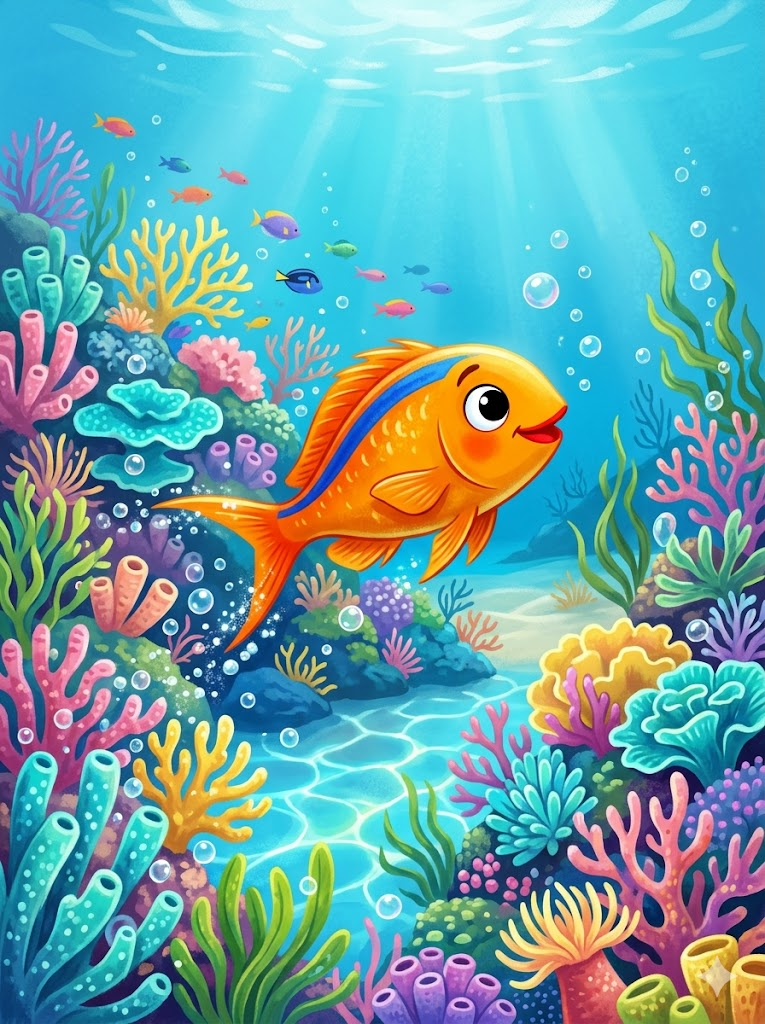

In [26]:
path_primera_imagen = "ilustraciones/primera_parte.jpg"

if os.path.exists(path_primera_imagen):
    display(Image(filename = path_primera_imagen, width=400))
else:
    print("Guarda la imagen en la carpeta ilustraciones con el nombre 'primera_parte.jpg'")

### Modelo Qwen3-VL para identificación y descripción del dibujo del segundo animal

Nuevamente abrimos la ventana de dibujo, esta vez preguntando por el nuevo animal.

In [33]:
root = tk.Tk()  # Creamos una ventana básica en blanco
app = AplicacionDibujo(root, modo_edad=False)

# Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
root.mainloop()

if app.imagen_resultado is not None:
    print("La imagen ha sido guardada.")
    img_animal_2 = app.imagen_resultado
else:
    print("La ventana se cerró sin guardar la imagen.")

La imagen ha sido guardada.


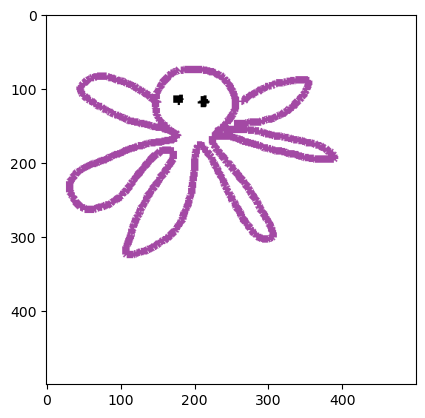

In [34]:
plt.imshow(img_animal_2)

Volvemos a aplicar el modelo Qwen3-VL, el mismo prompt específico (ver `descripcion_dibujo`) para obtener el formato en la salida deseada.

In [37]:
desc_2 = descripcion_dibujo.descripcion(img_animal_2)

desc_2 = desc_2[0].split("assistant")[1].strip()
desc_sep_2 = desc_2.strip().split('\n')
animal_2 = desc_sep_2[0].replace("Animal: ", "").strip()
descripcion_2 = desc_sep_2[1].replace("Description: ", "").strip()

In [39]:
print("Animal:", animal_2)
print("Descripción:", descripcion_2)

Animal: Octopus
Descripción: A purple octopus with a round body, eight arms, and two small black eyes.


### API Gemini para generación de la segunda parte de la historia

Generamos la segunda y parte final de la historia con la API de Gemini.

In [ ]:
prompt_2 = f'''Eres un experto escritor de cuentos infantiles en español que va a generar la segunda y parte final de un cuento. 
La primera parte del cuento, que tenía a un/una {animal} como protagonista de la historia, era:
"{cuento}"
La respuesta del niño a la pregunta final de la primera parte es un/una {animal_2} con las siguientes características: {descripcion_2} (no es necesario que esta descripción aparezca explícita en la segunda parte).
La edad del niño es {edad} años, por lo que debes utilizar un vocabulario apropiado para esa etapa de desarrollo vital.
Es la parte final de la historia, por lo que la trama debe cerrarse. Además, el cuento debe estar escrito específicamente para que lo entienda un niño de {edad} años, utilizando un vocabulario apropiado para esa etapa de desarrollo vital.
Debes tener en cuenta que el texto será leído por un narrador en voz alta, y que se generará una dibujo a partir de él, por lo que debe ser descriptivo y con pausas.
Por último, añade un cuarto párrafo adicional que tenga explícitamente la palabra "Moraleja:" seguida de una pequeña conclusión o moraleja sobre la historia para un niño de {edad} años (directamente, sin decir cosas como "Este cuento nos enseña...").
REGLA DE INCONGRUENCIA: Evalua si este segundo animal dado por el niño tiene sentido en el entorno actual de la historia. Si el animal NO pega, no cambies el entorno. En su lugar, justifica su peresencia de forma súper creativa, divertida o mágica.'''

respuesta = cliente.models.generate_content(
    model = modelo, contents = prompt_2
)

cuento_2 = respuesta.text

print(cuento_2)

Volvemos a mostrar el cuento por pantalla de forma elegante.

In [5]:
console = Console()
console.print(Panel(cuento_2, expand=False), justify="full")

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Aquel misterioso ser era un pulpo de color morado intenso, con  un  cuerpo  redondito  que  parecía  una  suave │
│ burbuja flotando en las profundidades. Sus ocho brazos largos se movían ondulando  con  mucha  calma,  como  si │
│ estuvieran bailando una música que solo él podía escuchar. Tenía dos ojitos negros, pequeños y brillantes,  que │
│ miraban a Rayo con muchísima curiosidad y dulzura. El pulpo extendió uno de sus tentáculos con cuidado  y  tocó │
│ suavemente la arena, invitando al pececito naranja a acercarse sin miedo para jugar.                            │
│                                                                                                                 │
│ Rayo, que siempre había sido muy valiente, nadó rápidamente alrededor del pulpo, dejando una estela azul con su │
│ raya de velocidad. El pulpo, emocionado por tener un nuevo amigo, empezó a soltar pequeñas burbujas y a cambiar │
│ un poquito su color para mostrar lo feliz que estaba. Juntos exploraron los escondites de  la  arena  blanca  y │
│ descubrieron caracolas que brillaban como si fueran tesoros escondidos. Rayo se dio cuenta de  que,  aunque  su │
│ nuevo amigo tenía muchos brazos y una forma extraña, era  el  compañero  de  juegos  más  divertido  que  había │
│ encontrado en todo el océano.                                                                                   │
│                                                                                                                 │
│ Cuando el sol empezó a ocultarse y el agua se volvió de un tono azul oscuro, Rayo supo que era  el  momento  de │
│ regresar a su hogar de coral. Se despidió del pulpo morado moviendo su colita puntiaguda con fuerza y  prometió │
│ volver al día siguiente para seguir explorando. Mientras  nadaba  de  regreso,  Rayo  se  sentía  muy  feliz  y │
│ orgulloso de sí mismo. Había descubierto que el mundo más allá de la roca gris no solo era  grande  y  hermoso, │
│ sino que estaba lleno de amigos maravillosos esperando a ser conocidos.                                         │
│                                                                                                                 │
│ Moraleja: La verdadera aventura no está solo en viajar lejos, sino en perder el miedo  a  lo  desconocido  para │
│ descubrir que las diferencias de los demás pueden regalarnos las mejores amistades.                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Modelo T2S Edge API Microsoft para la generación de la voz del narrador

Generamos la voz del narrador con el modelo Edge TTS.

In [ ]:
if os.path.exists("cuento_2.mp3"):
    os.remove("cuento_2.mp3")

await crear_audiolibro(cuento_2, archivo_salida = "cuento_2.mp3")

Reproducimos la narración de la segunda parte.

In [ ]:
reproducir_audio("cuento_2.mp3")

### Nano Banana 2 (I2T) (desde la web) para la generación de la ilustración de la segunda parte de la historia.

In [ ]:
prompt = "Genera una segunda ilustración para el cuento infantil a partir de la segunda parte de la historia, donde aparezcan ambos protagonista. No debe aparecer texto en la imagen. El ratio de la imagen de salida debe ser de 3:4:\n" + cuento_2

prompt

'Genera una segunda ilustración para el cuento infantil a partir de la segunda parte de la historia, donde aparezcan ambos protagonista. No debe aparecer texto en la imagen. El ratio de la imagen de salida debe ser de 3:4:\nAquel misterioso ser era un pulpo de color morado intenso, con un cuerpo redondito que parecía una suave burbuja flotando en las profundidades. Sus ocho brazos largos se movían ondulando con mucha calma, como si estuvieran bailando una música que solo él podía escuchar. Tenía dos ojitos negros, pequeños y brillantes, que miraban a Rayo con muchísima curiosidad y dulzura. El pulpo extendió uno de sus tentáculos con cuidado y tocó suavemente la arena, invitando al pececito naranja a acercarse sin miedo para jugar.\n\n\nRayo, que siempre había sido muy valiente, nadó rápidamente alrededor del pulpo, dejando una estela azul con su raya de velocidad. El pulpo, emocionado por tener un nuevo amigo, empezó a soltar pequeñas burbujas y a cambiar un poquito su color para most

Obtenemos la siguiente imagen:

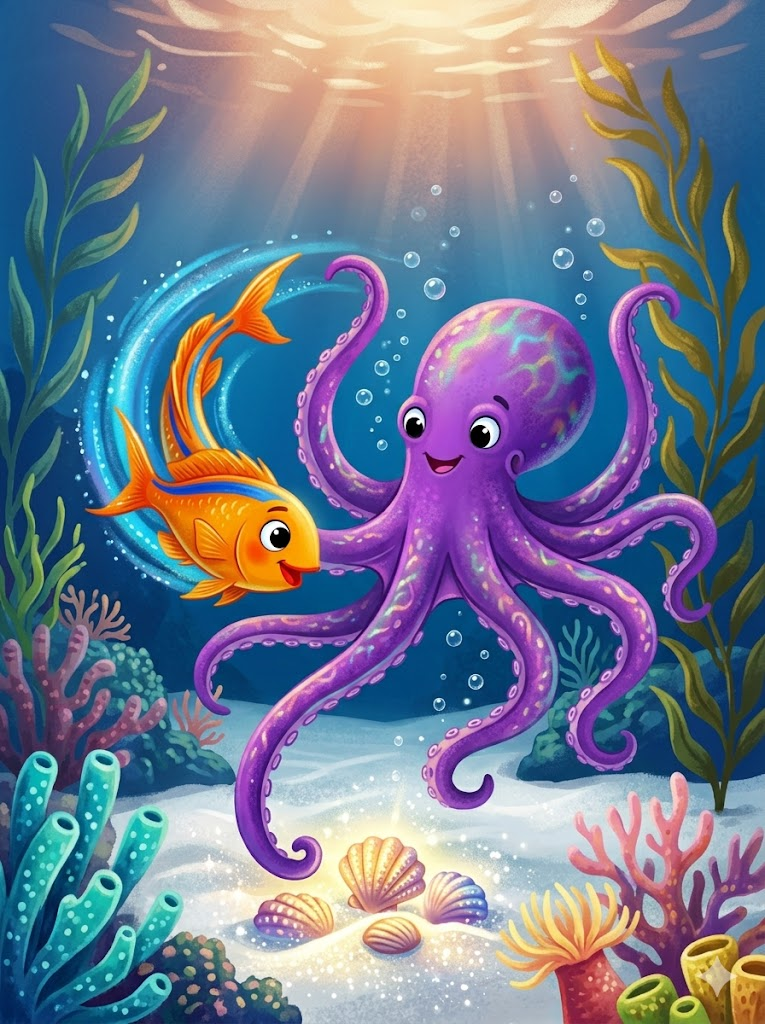

In [27]:
path_segunda_imagen = "ilustraciones/segunda_parte.jpg"

if os.path.exists(path_segunda_imagen):
    display(Image(filename = path_segunda_imagen, width=400))
else:
    print("Guarda la imagen en la carpeta ilustraciones con el nombre 'segunda_parte.jpg'")